# Phase 1 Training - Feature Extraction

Clean Phase 1 training with exact working configuration:
- **30 epochs** (reduced from 40 to minimize overfitting risk)
- **No data augmentation** (train on clean data)
- **ResNet50 preprocess_input** (critical fix applied)
- **Frozen backbone** (only train custom head)

**Target:** 65-70% validation accuracy

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
)
from datetime import datetime
from pathlib import Path
import json

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.15.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configuration

In [3]:
# Paths
PROJECT_ROOT = Path('/Users/nadaashraf/Desktop/FER copy')
DATA_DIR = PROJECT_ROOT / 'data' / 'fer2013'
MODELS_DIR = PROJECT_ROOT / 'models'
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints'
LOGS_DIR = PROJECT_ROOT / 'logs'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'

# Create directories
for dir_path in [MODELS_DIR, CHECKPOINTS_DIR, LOGS_DIR, OUTPUT_DIR]:
    dir_path.mkdir(exist_ok=True)

# Training parameters - PHASE 1 CONFIGURATION
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30  # Reduced from 40 to minimize overfitting risk
LEARNING_RATE = 1e-3
DROPOUT_RATE = 0.5
SEED = 42

# Load class indices
with open(PROJECT_ROOT / 'class_indices.json', 'r') as f:
    class_indices = json.load(f)

EMOTIONS = list(class_indices.keys())
NUM_CLASSES = len(EMOTIONS)

# Create experiment ID
EXPERIMENT_ID = f"phase1_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

print(f'\nPhase 1 Training Configuration:')
print(f'Experiment ID: {EXPERIMENT_ID}')
print(f'Epochs: {EPOCHS}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Learning rate: {LEARNING_RATE}')
print(f'Data augmentation: None')
print(f'Preprocessing: ResNet50 preprocess_input')
print(f'Backbone: Frozen ResNet50')


Phase 1 Training Configuration:
Experiment ID: phase1_20251213_181315
Epochs: 30
Batch size: 32
Learning rate: 0.001
Data augmentation: None
Preprocessing: ResNet50 preprocess_input
Backbone: Frozen ResNet50


## Load Data

**CRITICAL:** Using `preprocess_input` from ResNet50 (not manual normalization)

In [4]:
# Phase 1: No augmentation, only ResNet50 preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # CRITICAL FIX
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    DATA_DIR / 'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

# Validation generator
val_generator = train_datagen.flow_from_directory(
    DATA_DIR / 'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    DATA_DIR / 'test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'\nData loaded:')
print(f'Training samples: {train_generator.samples}')
print(f'Validation samples: {val_generator.samples}')
print(f'Test samples: {test_generator.samples}')

Found 53104 images belonging to 8 classes.
Found 13275 images belonging to 8 classes.
Found 3573 images belonging to 8 classes.

Data loaded:
Training samples: 53104
Validation samples: 13275
Test samples: 3573


## Build Model

In [5]:
def build_model_phase1():
    """
    Build ResNet50 model for Phase 1 (feature extraction).
    - Frozen ResNet50 backbone
    - Train only custom classification head
    """
    # Load ResNet50 with ImageNet weights
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    
    # Freeze all ResNet50 layers
    base_model.trainable = False
    
    # Build custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = Dense(256, activation='relu', name='fc1')(x)
    x = BatchNormalization(name='bn1')(x)
    x = Dropout(DROPOUT_RATE, name='dropout1')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    # Create model
    model = Model(inputs=base_model.input, outputs=outputs, name='ResNet50_FER_Phase1')
    
    return model, base_model

# Build model
model, base_model = build_model_phase1()

# Count parameters
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = sum([tf.size(w).numpy() for w in model.non_trainable_weights])

print(f'\nModel built: {model.name}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Non-trainable parameters: {non_trainable_params:,}')
print(f'Backbone frozen: {not base_model.trainable}')

2025-12-13 18:13:32.755715: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-12-13 18:13:32.755752: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-12-13 18:13:32.755766: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-12-13 18:13:32.755812: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-13 18:13:32.755830: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



Model built: ResNet50_FER_Phase1
Trainable parameters: 527,112
Non-trainable parameters: 23,588,224
Backbone frozen: True


## Compile Model

In [6]:
# Compile model
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Model compiled')
print(f'Optimizer: Adam (lr={LEARNING_RATE})')
print(f'Loss: categorical_crossentropy')

Model compiled
Optimizer: Adam (lr=0.001)
Loss: categorical_crossentropy


## Setup Callbacks

In [7]:
# Define callbacks
callbacks = [
    # Save best model
    ModelCheckpoint(
        filepath=str(CHECKPOINTS_DIR / f'{EXPERIMENT_ID}_best.keras'),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    
    # Early stopping
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate on plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    
    # TensorBoard
    TensorBoard(
        log_dir=str(LOGS_DIR / EXPERIMENT_ID),
        histogram_freq=1
    )
]

print(f'Callbacks configured:')
print('- ModelCheckpoint (best val_accuracy)')
print('- EarlyStopping (patience=10)')
print('- ReduceLROnPlateau (factor=0.5, patience=5)')
print('- TensorBoard')

Callbacks configured:
- ModelCheckpoint (best val_accuracy)
- EarlyStopping (patience=10)
- ReduceLROnPlateau (factor=0.5, patience=5)
- TensorBoard


## Train Model

**Phase 1 Training:** 30 epochs, frozen backbone, no augmentation

In [8]:
# Train model
print(f'\nStarting Phase 1 training... ({EPOCHS} epochs)')
print(f'Expected time: ~{EPOCHS * train_generator.samples / (BATCH_SIZE * 60):.0f} minutes\n')

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Phase 1 training complete!')


Starting Phase 1 training... (30 epochs)
Expected time: ~830 minutes

Epoch 1/30


2025-12-13 18:14:27.125946: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-12-13 18:14:27.199700: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


1660/1660 [==============================] - ETA: 0s - loss: 1.2049 - accuracy: 0.5823
Epoch 1: val_accuracy improved from -inf to 0.65137, saving model to /Users/nadaashraf/Desktop/FER copy/checkpoints/phase1_20251213_181315_best.keras
1660/1660 [==============================] - 181s 108ms/step - loss: 1.2049 - accuracy: 0.5823 - val_loss: 1.0141 - val_accuracy: 0.6514 - lr: 0.0010
Epoch 2/30
1660/1660 [==============================] - ETA: 0s - loss: 0.9387 - accuracy: 0.6680
Epoch 2: val_accuracy improved from 0.65137 to 0.66991, saving model to /Users/nadaashraf/Desktop/FER copy/checkpoints/phase1_20251213_181315_best.keras
1660/1660 [==============================] - 178s 107ms/step - loss: 0.9387 - accuracy: 0.6680 - val_loss: 0.9804 - val_accuracy: 0.6699 - lr: 0.0010
Epoch 3/30
1660/1660 [==============================] - ETA: 0s - loss: 0.8677 - accuracy: 0.6912
Epoch 3: val_accuracy improved from 0.66991 to 0.71051, saving model to /Users/nadaashraf/Desktop/FER copy/checkpo

## Evaluate on Test Set

In [10]:
from tensorflow.keras.models import load_model

BEST_MODEL_PATH = "/Users/nadaashraf/Desktop/FER copy/checkpoints/phase1_20251213_181315_best.keras"

print("Loading best model...")
model = load_model(BEST_MODEL_PATH)

print('\nEvaluating on test set...')
test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print("\n===== FINAL TEST RESULTS =====")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")


Loading best model...



Evaluating on test set...
112/112 [==============================] - 10s 84ms/step - loss: 0.8753 - accuracy: 0.6941

===== FINAL TEST RESULTS =====
Test Loss: 0.8753
Test Accuracy: 0.6941 (69.41%)


## Visualize Training History

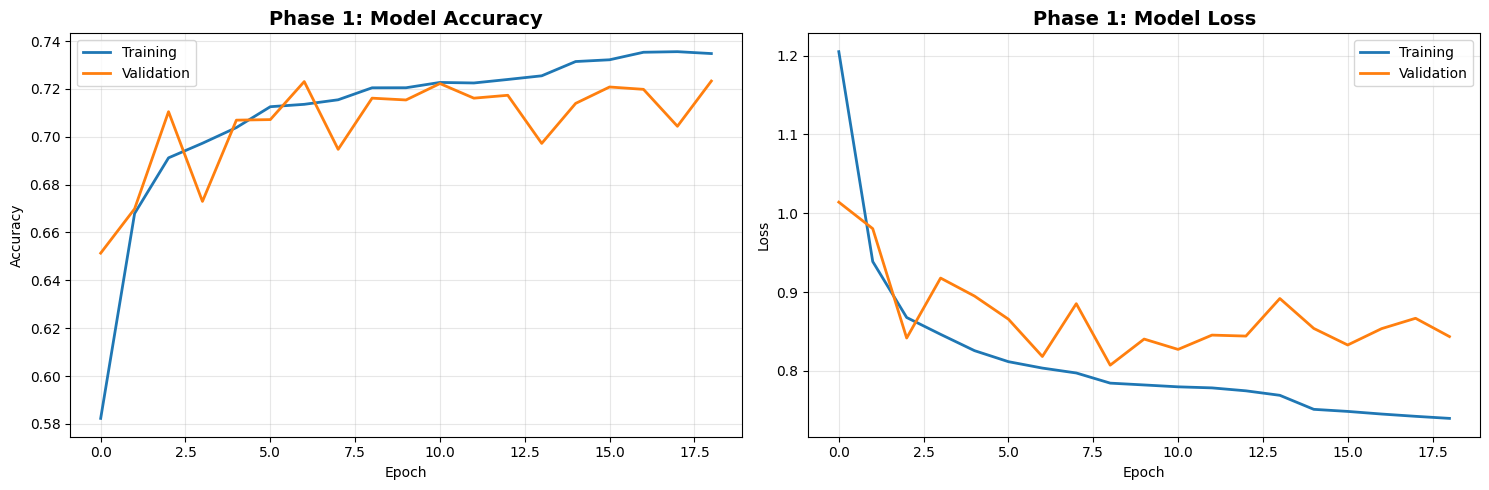


Best Results (Epoch 19):
Training Accuracy: 0.7348 (73.48%)
Validation Accuracy: 0.7233 (72.33%)
Overfitting Gap: 1.15%


In [11]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Phase 1: Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Phase 1: Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'{EXPERIMENT_ID}_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Print best results
best_epoch = np.argmax(history.history['val_accuracy'])
best_val_acc = history.history['val_accuracy'][best_epoch]
best_train_acc = history.history['accuracy'][best_epoch]

print(f'\nBest Results (Epoch {best_epoch + 1}):')
print(f'Training Accuracy: {best_train_acc:.4f} ({best_train_acc*100:.2f}%)')
print(f'Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'Overfitting Gap: {(best_train_acc - best_val_acc)*100:.2f}%')

## Save Model and Results

In [12]:
# Save final model
final_model_path = MODELS_DIR / f'{EXPERIMENT_ID}_final.keras'
model.save(final_model_path)
print(f'\nFinal model saved: {final_model_path}')

# Save training history
history_dict = {
    'experiment_id': EXPERIMENT_ID,
    'phase': 'Phase 1 - Feature Extraction',
    'epochs_trained': len(history.history['loss']),
    'best_epoch': int(best_epoch + 1),
    'best_train_acc': float(best_train_acc),
    'best_val_acc': float(best_val_acc),
    'test_acc': float(test_acc),
    'test_loss': float(test_loss),
    'history': {
        'accuracy': [float(x) for x in history.history['accuracy']],
        'val_accuracy': [float(x) for x in history.history['val_accuracy']],
        'loss': [float(x) for x in history.history['loss']],
        'val_loss': [float(x) for x in history.history['val_loss']]
    },
    'config': {
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'augmentation': 'None',
        'preprocessing': 'ResNet50 preprocess_input',
        'backbone_frozen': True
    }
}

with open(OUTPUT_DIR / f'{EXPERIMENT_ID}_history.json', 'w') as f:
    json.dump(history_dict, f, indent=2)

print(f'Training history saved: {OUTPUT_DIR / f"{EXPERIMENT_ID}_history.json"}')


Final model saved: /Users/nadaashraf/Desktop/FER copy/models/phase1_20251213_181315_final.keras
Training history saved: /Users/nadaashraf/Desktop/FER copy/outputs/phase1_20251213_181315_history.json


## Summary

**Phase 1 Training Complete!**

**Configuration:**
- ✅ 30 epochs (reduced from 40)
- ✅ No data augmentation
- ✅ ResNet50 preprocess_input (CRITICAL FIX)
- ✅ Frozen backbone (feature extraction)

**Expected Results:**
- Baseline validation accuracy: 65-70%
- Test accuracy should be similar to validation
- Low overfitting (small train/val gap)

**Next Steps:**
1. Analyze results with evaluation notebook
2. If baseline is good (≥65%), proceed to Phase 2 fine-tuning
3. If baseline is low (<60%), review data quality and preprocessing